This notebook shows the implementation of a logistic regression model in Numpy. A linear and a polynomial regression model are trained and compared with the Scikit-learn implementation via the learned parameters of the model and a quick evaluation on model accuracy.

The notebook shows:
1. **Implementation of Logistic Regression in Numpy**
2. **Linear Logistic Regression**
3. **Polynomial Logistic Regression**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utilities_notebook import zscore_normalize_features, apply_zscore_normalization

pd.options.display.float_format = '{:0.4f}'.format
np.set_printoptions(precision=4, suppress=True)

In [2]:
X_train = pd.read_csv("../data/linear/X_train.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("../data/linear/y_train.csv", index_col=0, parse_dates=True)
X_test = pd.read_csv("../data/linear/X_test.csv", index_col=0, parse_dates=True)
y_test = pd.read_csv("../data/linear/y_test.csv", index_col=0, parse_dates=True)

print(f"Shape\n"
      f"X_train: {X_train.shape}, y_train: {y_train.shape}\n"
      f"X_test:  {X_test.shape}, y_test : {y_test.shape}\n")

X_train.head()

Shape
X_train: (567, 6), y_train: (567, 1)
X_test:  (144, 6), y_test : (144, 1)



,volume,pct_change_1d,rsi,adx,corr,volatility
Date,,,,,,
2023-02-02,8523200,-0.0263,25.7173,20.0378,0.6622,1.5033
2023-02-03,9219400,0.0270,39.1583,23.3030,0.7018,1.8069
2023-02-07,11662300,-0.0368,30.5574,27.4839,0.8373,2.0947
2023-02-08,5665300,0.0109,35.0839,31.2467,0.8722,2.1606
2023-02-09,6074700,0.0054,37.3525,33.7869,0.8379,2.1827


## 1 Implementation of Logistic Regression in Numpy

- Methodology
- Logistic regression model
- Cost function
- Learning algorithm

**Credit**: I started this project after going through the first part of Andrew Ng's machine learning specialization: Supervised Machine Learning. Hence, all credit goes to Andrew Ng and his team. I wrote these functions myself from scratch to make sure I understood it.

Initially I had written them with Pandas but ultimately found Numpy easier to work with when manipulating and moving data around. My implementation is the same as Andrew Ng's except that I had used vectorization for calculations and some minor adjustments.
___

#### Methodology:  
1) Compute the cost function
2) Compute the gradient for gradient descent updates
3) Perform batch gradient descent to learn the best fit parameters
4) Make a prediction on a sample based on learned parameters

#### The Logistic Regression Model:

$$f_{\mathbf{w},b}(\mathbf{x^{(i)}}) = g(\mathbf{x^{(i)}} \cdot \mathbf{w} + b)$$

where

* $\mathbf{w}$ is the vector of weight parameters of length $j$
* $b$ is the bias parameter
* $\mathbf{x^{(i)}}$ is the $i^{th}$ input feature vector with length $j$
* $\mathbf{x^{(i)}} \cdot \mathbf{w}$ is the dot product between vector $\mathbf{x^{(i)}}$ and $\mathbf{w}$
* $g$ is the sigmoid function

The sigmoid function $g$ outputs a value $f_{w,b}(x)$ where $-1<f_{w,b}(x)<1$ which can be interpreted as the probability of the sample being a positive class $1$ or negative class $0$ based on a threshold value $p$.

The sigmoid function is defined as
$$g(z) = \frac{1}{1+e^{-z}}$$

In [3]:
# sigmoid function

def sigmoid(X):
    X = np.clip(X, -500, 500) # protect against overflow
    return 1/(1+np.exp(-X))

#### Cost function

In order to find the best fit parameters $\mathbf{w}$ and $b$ for the model, a cost function $J(w,b)$ has to be defined which is a metric that tells us how well a model fits to the data.

$$J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1}[loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)},y^{(i)}))]$$

where $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)},y^{(i)}))$ is the logistic loss function or Binary Cross-Entropy loss function for a single data point.

$$
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)},y^{(i)})) =
\begin{cases}
-\log(f_{\mathbf{w},b}(\mathbf{x^{(i)}})) & \text{if } y^{(i)} = 1 \\ 
-\log(1 - f_{\mathbf{w},b}(\mathbf{x^{(i)}})) & \text{if } y^{(i)} = 0
\end{cases}
$$

* $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) \in (-1,1)$ is the model's prediction for the $i^{th}$ example
* $y^{(i)}$ is the target value for the $i^{th}$ example

The Binary Cross-Entropy loss function is a convex function which has the property of having a global minimum, which is a single minimum cost.

In [4]:
# compute cost function

def compute_cost(X, y, w, b, lambda_=0):
    """
    Computes cost

    Args:
        X (ndarray (m,n)) : Data, m examples with n features
        y (ndarray (m,))  : target values
        w (ndarray (n,))  : model parameters
        b (scalar)        : model parameter
    
    Returns:
        cost (scalar)     : cost
    """
    m = X.shape[0]
    z = X @ w + b
    f_wb = sigmoid(z)
    
    # Clip f_wb to be between a tiny epsilon and 1-epsilon
    epsilon = 1e-15
    f_wb = np.clip(f_wb, epsilon, 1 - epsilon)
    
    loss = -y * np.log(f_wb) - (1-y) * np.log(1-f_wb)
    regularized_cost = lambda_ / (2*m) * np.sum(w**2)

    return np.sum(loss) / m + regularized_cost

#### Learning algorithm

Then it follows logically that the best fit parameters $w$ and $b$ would be the model with the least possible value of $J(w,b)$.

Fortunately, this can be done via a learning algorithm called Gradient Descent.

Gradient descent is an algorithm that updates a model's parameters in the direction of steepest descent which we use to iteratively minimize the cost function.

At each iteration, the weight parameter $w_j$ and bias b is updated via

$$
\begin{aligned}
&\text{repeat until convergence: }\{ \\
    &w_j = w_j - \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} && \text{for } j = 0, ..., n-1 \\
    &b = b - \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
\} 
\end{aligned}
$$

where

* $\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=0}^{m-1}(f_{\mathbf{w},b}(\mathbf{x^{(i)}}) - y^{(i)})x_{j}^{(i)}$ is the gradient of cost $J$ with respect to $w_j$

* $\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1}(f_{\mathbf{w},b}(\mathbf{x^{(i)}}) - y^{(i)})$ is the gradient of bias $b$
* $\alpha$ is the learning rate for each iteration
* $m$ is the number of training examples in the data set

In [5]:
def compute_gradient(X, y, w, b, lambda_=0):
    """
    Computes the gradient for logistic regression 

    Args:
      X (ndarray (m,n)) : data, m examples by n features
      y (ndarray (m,))  : target value 
      w (ndarray (n,))  : values of parameters of the model
      b (scalar)        : value of bias parameter of the model

    Returns
      dj_dw (ndarray (n,)) : The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)       : The gradient of the cost w.r.t. the parameter b. 
    """
    m = X.shape[0]

    # Linear combination and activation
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    err = f_wb - y

    # Gradient calculation using matrix multiplication
    dj_dw = np.dot(X.T, err) / m + lambda_ / m * w
    dj_db = np.sum(err) / m

    return dj_dw, dj_db

In [6]:
def run_gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m, n))      : data, m examples by n features
      y (ndarray (m,))        : target value 
      w_in (ndarray (n,))     : Initial values of parameters of the model
      b_in (scalar)           : Initial value of parameter of the model
      cost_function           : function to compute cost
      gradient_function       : function to compute gradient
      alpha (float)           : Learning rate
      num_iters (int)         : number of iterations to run gradient descent
      lambda_ (scalar, float) : regularization constant
      
    Returns:
      w (ndarray (n,))        : Updated values of parameters of the model
      b (scalar)              : Updated value of parameter of the model
    """
    J_history = [] # save the cost J at each iteration for plotting
    w = np.copy(w_in)
    b = b_in

    for i in range(num_iters):
        # Calculate gradient and update parameters
        dj_dw, dj_db = gradient_function(X, y, w, b, lambda_)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Save cost J at each iteration
        cost = cost_function(X, y, w, b, lambda_)
        J_history.append(cost)

        # Print cost at intervals 10% of num_iters
        if i % (num_iters // 10) == 0 or i == (num_iters - 1):
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.5f}")
    
    # Plot the cost J at each iteration
    plt.figure(figsize=(6,4))
    plt.plot(J_history)
    plt.title('Cost over time')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.show()
    
    return w, b

Lastly, *predict()* is a function that predicts an output vector $\hat{y}$ from an input feature matrix $X$ with a hyperparameter threshold value $p$.

$p = 0.5$ is usually the default but it is tunable to suit a specific application.

In [7]:
def predict(X, w, b, p=0.5):
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
      X (ndarray (m,n)) : data, m examples by n features
      w (ndarray (n,))  : values of parameters of the model      
      b (scalar)        : value of bias parameter of the model
      p (float)         : decision threshold for binary classification

    Returns:
      f_wb (ndarray (m,)) : The predicted probabilities of samples in X being the positive class=1
      pred (ndarray (m,))    : The predictions for samples in X using a threshold value p
    """
    f_wb = sigmoid(X @ w + b)

    pred = np.where(f_wb >= p, 1, 0)

    return f_wb, pred

## 2 Linear logistic regression

- Training a linear logistic regression model
- Comparing manual implementation with Scikit-learn's implementation

#### Training a linear logistic regression model

We normalize the features that were decided for normalization during the pre-processing stage.
- Linear Logistic Regression: *volume*, *pct_change_1d*, *rsi*, *adx*
- Polynomial Logistic Regression: all 23 features except *corr*, *volatility*, *corr^2*, *pct_change_1d\*volatility*

In [8]:
features = ['volume', 'pct_change_1d', 'rsi', 'adx']
X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns=features)
X_test_norm, X_test_mu, X_test_sigma = zscore_normalize_features(X_test, columns=features)

Iteration    0: Cost  0.68841
Iteration 1000: Cost  0.64151
Iteration 2000: Cost  0.64149
Iteration 3000: Cost  0.64149
Iteration 4000: Cost  0.64149
Iteration 5000: Cost  0.64149
Iteration 6000: Cost  0.64149
Iteration 7000: Cost  0.64149
Iteration 8000: Cost  0.64149
Iteration 9000: Cost  0.64149
Iteration 9999: Cost  0.64149


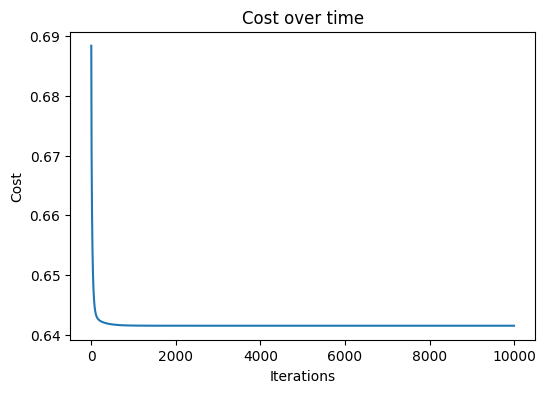

In [9]:
# initialize parameters w and b to 0 before training
w_in = np.zeros(X_train_norm.shape[1])
b_in = 0

w, b = run_gradient_descent(X_train_norm.values, y_train.values.reshape(-1), w_in, b_in, compute_cost,
                            compute_gradient, alpha=0.1, num_iters=10000, lambda_=0)

The learning curve shows a healthy exponential decrease in cost over number of iterations.

It seems like a global minimum is reached between iterations 1000 and 2000.

In [10]:
f_wb, p = predict(X_train_norm, w, b)
print(f"Accuracy on training set: {np.mean(p==y_train['signal'].values) * 100:.2f}%")

X_test_norm = apply_zscore_normalization(X_test, X_train_mu, X_train_sigma, columns=features)
f_wb2, p2 = predict(X_test_norm, w, b)
print(f"Accuracy on test set: {np.mean(p2==y_test['signal'].values) * 100:.2f}%")

Accuracy on training set: 61.73%
Accuracy on test set: 54.17%


A quick evaluation of our classification model shows a 61.90% training accuracy which is not bad for an elementary model and by only using 2 primary sources of information - price and volume.

Accuracy on the test set however dropped slightly which is expected but shows moderate generalization at 55.56%.

Evaluating classification models however require slighly more metrics which will be covered in more depth in the next notebook.

#### Comparing manual implementation with Scikit-learn's implementation

In [11]:
# comparing it with the logistic regression model from scikit-learn

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)

model.fit(X_train_norm, y_train['signal'])

w_sklearn = model.coef_
b_sklearn = model.intercept_

y_hat = model.predict(X_train_norm)
print(f"Accuracy on training set: {model.score(X_train_norm, y_train['signal']) * 100:0.2f}%")

y_hat2 = model.predict(X_test_norm)
print(f"Accuracy on test set: {model.score(X_test_norm, y_test['signal']) * 100:0.2f}%")

Accuracy on training set: 61.73%
Accuracy on test set: 54.17%


c:\Users\DELL\Workspace\project_01_v2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


The result of Scikit-learn's implementation is exactly the same as ours.

In [12]:
print(f"w_manual  : {w}, b_manual: {b:0.4f}"
      f"\nw_sklearn : {w_sklearn.flatten()}, b_sklearn: {b_sklearn[0]:0.4f}")

w_manual  : [ 0.4589 -0.3076 -0.1973 -0.0664  0.2505 -0.0271], b_manual: -0.4212
w_sklearn : [ 0.459  -0.3076 -0.1973 -0.0664  0.2504 -0.027 ], b_sklearn: -0.4213


The learned parameters of the model - weights and bias - are nearly identical, which shows two things:
1. The numpy implementation of the cost function for logistic regression and the learning algorithm - gradient descent - were implemented correctly as intended.
2. It confirms that there is a global minimum for our cost function (not mathematically proven here), which also supports our initial assumption that the cost function is indeed convex.

In [13]:
np.savetxt("../data/linear/pred.csv", p2)

## 3 Polynomial logistic regression

#### Training a polynomial regression model

In [14]:
X_poly_train = pd.read_csv("../data/poly/X_poly_train.csv", index_col=0, parse_dates=True)
y_poly_train = pd.read_csv("../data/poly/y_poly_train.csv", index_col=0, parse_dates=True)
X_poly_test = pd.read_csv("../data/poly/X_poly_test.csv", index_col=0, parse_dates=True)
y_poly_test = pd.read_csv("../data/poly/y_poly_test.csv", index_col=0, parse_dates=True)

print(f"Shape\n"
      f"X_poly_train: {X_poly_train.shape}, y_poly_train: {y_poly_train.shape}\n"
      f"X_poly_test:  {X_poly_test.shape}, y_poly_test : {y_poly_test.shape}\n")

X_poly_train.head()

Shape
X_poly_train: (562, 27), y_poly_train: (562, 1)
X_poly_test:  (144, 27), y_poly_test : (144, 1)



,volume,pct_change_1d,rsi,adx,corr,volatility,volume^2,pct_change_1d^2,rsi^2,adx^2,...,pct_change_1d*rsi,pct_change_1d*adx,pct_change_1d*corr,pct_change_1d*volatility,rsi*adx,rsi*corr,rsi*volatility,adx*corr,adx*volatility,corr*volatility
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-02,8523200,-0.0263,25.7175,20.0381,0.6622,1.5033,72644938240000,0.0007,661.3877,401.5269,...,-0.6768,-0.5273,-0.0174,-0.0396,515.3299,17.0313,38.6605,13.2702,30.1229,0.9955
2023-02-03,9219400,0.0270,39.1583,23.3034,0.7018,1.8069,84997336360000,0.0007,1533.3753,543.0486,...,1.0583,0.6298,0.0190,0.0488,912.5225,27.4802,70.7535,16.3537,42.1059,1.2680
2023-02-07,11662300,-0.0368,30.5574,27.4843,0.8373,2.0947,136009241290000,0.0014,933.7563,755.3845,...,-1.1258,-1.0126,-0.0308,-0.0772,839.8482,25.5844,64.0074,23.0114,57.5702,1.7538
2023-02-08,5665300,0.0109,35.0840,31.2470,0.8722,2.1606,32095624090000,0.0001,1230.8836,976.3769,...,0.3834,0.3415,0.0095,0.0236,1096.2693,30.6019,75.8034,27.2552,67.5133,1.8846
2023-02-09,6074700,0.0054,37.3526,33.7873,0.8379,2.1827,36901980090000,0.0000,1395.2134,1141.5797,...,0.2019,0.1826,0.0045,0.0118,1262.0409,31.2961,81.5294,28.3089,73.7475,1.8288


In [15]:
exclude = ['corr', 'volatility', 'corr^2', 'pct_change_1d*volatility']
cols_to_scale = [c for c in X_poly_train.columns if c not in exclude]

X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns=cols_to_scale)

Iteration    0: Cost  0.68505
Iteration 5000: Cost  0.63304
Iteration 10000: Cost  0.63253
Iteration 15000: Cost  0.63226
Iteration 20000: Cost  0.63208
Iteration 25000: Cost  0.63196
Iteration 30000: Cost  0.63187
Iteration 35000: Cost  0.63180
Iteration 40000: Cost  0.63175
Iteration 45000: Cost  0.63171
Iteration 49999: Cost  0.63167


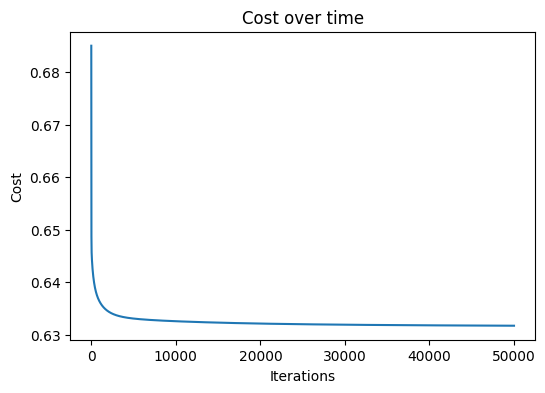

Train accuracy: 63.70%
Test Accuracy: 50.69%


In [16]:
w2_in = np.zeros(X_poly_train_norm.shape[1])
b2_in = 0

w2, b2 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w2_in, b2_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=0) # no regularization, the effect of regularization is shown in the next notebook

f_wb3, p3 = predict(X_poly_train_norm, w2, b2)
print(f"Train accuracy: {np.mean(p3==y_poly_train['signal'].values) * 100:0.2f}%")

X_poly_test_norm = apply_zscore_normalization(X_poly_test, X_poly_train_mu, X_poly_train_sigma, cols_to_scale)
f_wb4, p4 = predict(X_poly_test_norm, w2, b2)
print(f"Test Accuracy: {np.mean(p4 == y_poly_test['signal'].values) * 100:0.2f}%")

In [17]:
model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)

model.fit(X_poly_train_norm, y_poly_train['signal'])

w_sklearn = model.coef_      
b_sklearn = model.intercept_ 

y_hat3 = model.predict(X_poly_train_norm)
print(f"Accuracy on training set: {model.score(X_poly_train_norm, y_poly_train['signal']) * 100:0.2f}%")
y_hat4 = model.predict(X_poly_test_norm)
print(f"Accuracy on test set: {model.score(X_poly_test_norm, y_poly_test['signal']) * 100:0.2f}%")

Accuracy on training set: 63.70%
Accuracy on test set: 52.08%


c:\Users\DELL\Workspace\project_01_v2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
print(f"w_manual: {w2}, b_manual: {b2:0.4f}"
      f"\nw_sklearn:\n{w_sklearn}, b_sklearn: {b_sklearn}\n")

w_manual: [ 0.1715 -0.7466 -0.6013  0.1405  0.9113  0.7489  0.0461 -0.0955  0.5186
  0.8186  0.2433  0.1094  0.1451  0.1771 -0.2378  0.4127  0.1638  0.1102
  0.1485  0.0658  0.8506 -0.3058 -0.3008  0.018  -0.3405 -1.1068 -0.1504], b_manual: -2.2263
w_sklearn:
[[ 0.0854 -0.9801 -0.4053  0.1478  1.0463  1.214   0.064  -0.1215  0.4587
   0.8061  0.2472 -0.0419  0.0813  0.2675 -0.2247  0.401   0.1548  0.1789
   0.0871  0.0598  7.7038 -0.3129 -0.334  -0.2355 -0.3557 -1.1032 -0.1514]], b_sklearn: [-3.1689]



In [19]:
np.savetxt("../data/poly/pred2.csv", p4)